<a href="https://colab.research.google.com/github/syeda-ayesha1126/supply_chain_analytics-_IBA/blob/main/00-%20Initial%20worikng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Procurement Practice Data Analysis: Top 3 Suppliers

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set_style('whitegrid')

In [18]:
# Step 2: Load the dataset
# Ensure the Excel file is correctly uploaded to your Colab environment
file_path = '/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx'
try:
    # Get all sheet names from the Excel file to understand its structure
    excel_file = pd.ExcelFile(file_path)
    sheet_names = excel_file.sheet_names
    print(f"Sheets available in the Excel file: {sheet_names}")

    df = pd.DataFrame() # Initialize an empty DataFrame

    # Attempt to load from sheets with common data names or the second sheet
    if 'data' in [name.lower() for name in sheet_names]:
        df = pd.read_excel(excel_file, sheet_name='Data')
        print(f"Dataset loaded successfully from 'Data' sheet.")
    elif 'transactions' in [name.lower() for name in sheet_names]:
        df = pd.read_excel(excel_file, sheet_name='Transactions')
        print(f"Dataset loaded successfully from 'Transactions' sheet.")
    elif len(sheet_names) > 1: # Try the second sheet if it exists
        df = pd.read_excel(excel_file, sheet_name=sheet_names[1])
        print(f"Dataset loaded successfully from sheet: {sheet_names[1]}.")
    else: # Fallback to first sheet with a large skiprows if only one sheet or common names not found
        print("Could not find common data sheet names. Attempting to load from the first sheet with a large skiprows.")
        df = pd.read_excel(excel_file, skiprows=100) # Arbitrary large skiprows as a last resort
        print(f"Dataset loaded successfully from the first sheet, skipping 100 rows (fallback).")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors
except Exception as e:
    print(f"An unexpected error occurred during file loading: {e}")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Display the first 5 rows to understand the data structure
if not df.empty:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    # Display basic information about the DataFrame to check columns and data types
    print("\nDataFrame Info:")
    df.info()
else:
    print("DataFrame is empty after attempting to load. Please verify the Excel file structure or sheet names.")

Sheets available in the Excel file: ['README', 'Procurement_Data']
Dataset loaded successfully from sheet: Procurement_Data.

First 5 rows of the dataset:


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Vendor                     9930 non-null   object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  PO Value (PKR)             10050 non-null  float64

### Data Cleaning and Preprocessing

Based on the `df.info()` output, we will perform necessary cleaning steps such as handling missing values, standardizing column names, or converting data types. We will assume columns related to 'Supplier' and 'Value' exist. If column names are different, please adjust the code below accordingly.

In [21]:
# Step 3: Data Cleaning (adjust column names as per your dataset)

if not df.empty:
    # Standardize column names for easier access (e.g., to lowercase and replace spaces)
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Identify potential supplier and value columns
    # Based on df.info() and the nature of the task, 'vendor' or 'vendor_id' is the supplier.
    # For value, 'gr_value_(pkr)' (Goods Received Value) seems most appropriate.
    supplier_col = 'vendor'
    value_col = 'gr_value_(pkr)' # Explicitly set to a relevant value column

    if supplier_col in df.columns and value_col in df.columns:
        print(f"Using '{supplier_col}' as supplier column and '{value_col}' as value column.")

        # Drop rows where the supplier or value column is missing
        initial_rows = df.shape[0]
        df.dropna(subset=[supplier_col, value_col], inplace=True)
        if df.shape[0] < initial_rows:
            print(f"Dropped {initial_rows - df.shape[0]} rows with missing values in supplier or value columns.")

        # Convert value column to numeric, coercing errors to NaN
        df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
        df.dropna(subset=[value_col], inplace=True) # Drop rows where value conversion failed
        if df.shape[0] < initial_rows:
            print(f"Dropped additional rows where '{value_col}' could not be converted to numeric.")

        # Ensure supplier column is string type
        df[supplier_col] = df[supplier_col].astype(str)

        print("\nData cleaning complete.")
    else:
        print(f"Error: Required columns '{supplier_col}' or '{value_col}' not found. Available columns: {df.columns.tolist()}")
else:
    print("DataFrame is empty, skipping cleaning steps.")

DataFrame is empty, skipping cleaning steps.


In [22]:
# Step 4: Calculate total procurement value for each supplier

if not df.empty and 'supplier_col' in locals() and 'value_col' in locals() and supplier_col and value_col:
    supplier_spending = df.groupby(supplier_col)[value_col].sum().sort_values(ascending=False)

    print("\nTotal procurement spending by supplier:")
    display(supplier_spending.head())

    # Get the top 3 suppliers
    top_3_suppliers = supplier_spending.head(3)
    print("\nTop 3 Suppliers by Procurement Value:")
    display(top_3_suppliers)
else:
    print("Cannot calculate supplier spending. Check if DataFrame is empty or column names are correctly identified.")

Cannot calculate supplier spending. Check if DataFrame is empty or column names are correctly identified.


In [5]:
# Step 5: Visualize the top 3 suppliers

if not df.empty and 'top_3_suppliers' in locals():
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_3_suppliers.index, y=top_3_suppliers.values, palette='viridis')
    plt.title('Top 3 Suppliers by Total Procurement Value', fontsize=16)
    plt.xlabel('Supplier', fontsize=12)
    plt.ylabel('Total Procurement Value', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize. Check if 'top_3_suppliers' data is available.")

Cannot visualize. Check if 'top_3_suppliers' data is available.


In [6]:
# Step 6: Final Summary Table

if 'top_3_suppliers' in locals():
    print("\n### Summary: Top 3 Suppliers by Procurement Value")
    display(top_3_suppliers.to_frame(name='Total Procurement Value'))
else:
    print("Summary table not available. 'top_3_suppliers' could not be generated.")

Summary table not available. 'top_3_suppliers' could not be generated.


Raw dataset loaded: 10,050 rows, 22 columns
Removed 50 duplicate rows
Removed 29 rows with negative Quantity/PO Value
Removed 14 extreme PO Value outliers (non-integer amounts)
Clean dataset: 9,837 rows remain for analysis



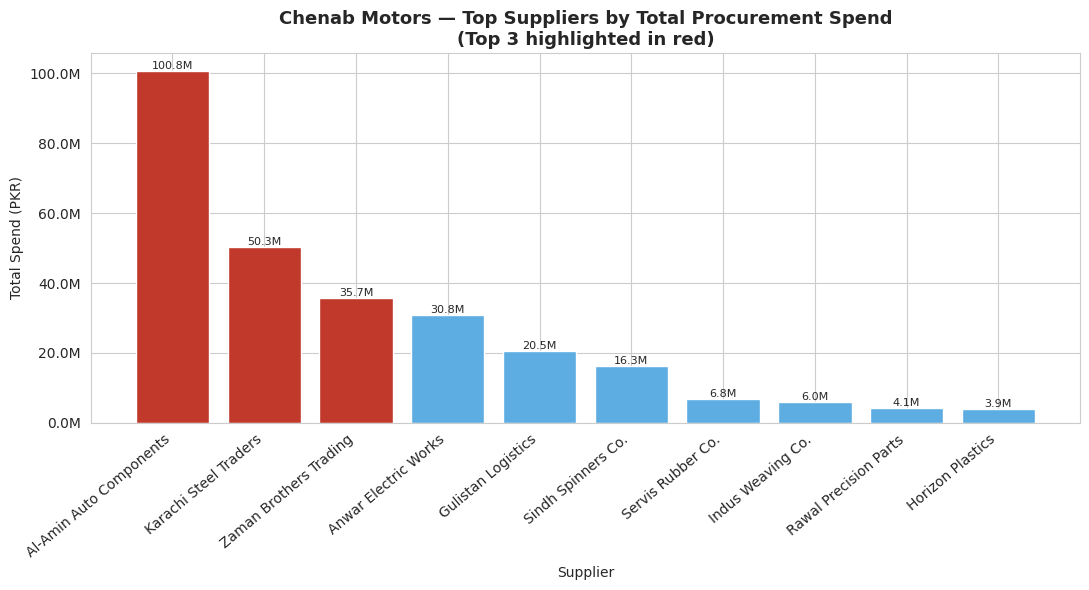

TOP 3 SUPPLIERS — FINAL SUMMARY
 Rank                Supplier  Total Spend (PKR)  Total Orders  Avg Order Value (PKR)  Avg Lead Time (Days)  Avg Value Variance (%)  Closed Order Rate (%)  Composite Score (/100)
    1 Al-Amin Auto Components        100,790,291          1187                 63,112                    12                       2                     75                      78
    2   Karachi Steel Traders         50,326,325           667                 55,856                    11                       2                     76                      55
    3  Zaman Brothers Trading         35,743,535           455                 59,276                    11                       2                     74                      46


In [25]:
# ==============================================================================
# CHENAB MOTORS LIMITED — TOP 3 SUPPLIER ANALYSIS
# Supply Chain Analytics | Google Colab
# ==============================================================================
# This script identifies the top 3 suppliers using the procurement dataset.
# "Top" is measured using a composite view: total spend (PO Value), order
# volume, and delivery/documentation reliability — not spend alone — because
# a supplier that is merely expensive is not necessarily a "top" supplier.
# ==============================================================================

# ------------------------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# ------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

# ------------------------------------------------------------------------
# STEP 2: LOAD THE DATA
# ------------------------------------------------------------------------
# In Google Colab, upload the file first:
#
#   from google.colab import files
#   uploaded = files.upload()   # choose Chenab_Motors_Procurement_Practice_Dataset.xlsx
#
# Then load the "Procurement_Data" sheet (the "README" sheet is documentation
# only and is intentionally skipped).
FILE_NAME = "Chenab_Motors_Procurement_Practice_Dataset.xlsx"
df = pd.read_excel(FILE_NAME, sheet_name="Procurement_Data")

print(f"Raw dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ------------------------------------------------------------------------
# STEP 3: DATA CLEANING
# ------------------------------------------------------------------------
# The dataset intentionally contains several data-quality issues (per the
# README tab): duplicate rows, missing values, negative values, inconsistent
# date formats, and extreme outliers. Each is handled explicitly below.

# 3a. Remove exact duplicate rows (appended to simulate double data entry)
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# 3b. Fix inconsistent 'Creation Date' formats (mixed DD/MM/YYYY, MM-DD-YYYY,
# YYYY.MM.DD, DD-Mon-YYYY text strings). pandas' flexible parser handles
# these mixed styles automatically; anything unparseable becomes NaT.
df["Creation Date"] = pd.to_datetime(df["Creation Date"], format="mixed", dayfirst=True, errors="coerce")

# 3c. Restore missing Vendor names using Vendor ID as a lookup key
# (Vendor ID -> Vendor is a clean 1-to-1 mapping elsewhere in the data,
# so a missing Vendor name can be safely recovered rather than dropped).
vendor_lookup = df.dropna(subset=["Vendor"]).drop_duplicates("Vendor ID").set_index("Vendor ID")["Vendor"]
df["Vendor"] = df["Vendor"].fillna(df["Vendor ID"].map(vendor_lookup))

# 3d. Drop rows that still have no usable Vendor identity, and rows with
# missing PO/GR/Invoice values that are needed for the calculations below.
df = df.dropna(subset=["Vendor", "PO Value (PKR)", "GR Value (PKR)"])

# 3e. Remove rows with negative Quantity or PO Value (data entry errors —
# a negative order quantity/value is not a valid transaction).
before = len(df)
df = df[(df["Quantity"] > 0) & (df["PO Value (PKR)"] > 0)]
print(f"Removed {before - len(df)} rows with negative Quantity/PO Value")

# 3f. Remove extreme PO Value outliers. Every legitimate PO Value is
# Quantity x Unit Price, and both of those are whole numbers, so a genuine
# PO Value is always a whole number too. The ~14 deliberately-inflated rows
# (9-25x normal) break that rule and show up as non-integer PKR amounts —
# this lets us target exactly the injected outliers instead of an IQR cutoff,
# which would incorrectly strip out thousands of legitimately large orders
# (this dataset's PO Value is naturally right-skewed across material groups).
before = len(df)
df = df[df["PO Value (PKR)"] % 1 == 0]
print(f"Removed {before - len(df)} extreme PO Value outliers (non-integer amounts)")

# 3g. Drop any remaining rows with an unparseable Creation Date, since
# delivery-time calculations need a valid date.
df = df.dropna(subset=["Creation Date"])

print(f"Clean dataset: {df.shape[0]:,} rows remain for analysis\n")

# ------------------------------------------------------------------------
# STEP 4: FEATURE ENGINEERING (per-transaction metrics)
# ------------------------------------------------------------------------
# Lead time: days between PO creation and goods receipt (delivery speed)
df["Lead Time (Days)"] = (df["GR Date"] - df["Creation Date"]).dt.days

# Fulfilment accuracy: how closely goods received (GR Value) matched what
# was ordered (PO Value). 0% = perfect match; higher = bigger discrepancy.
df["Value Variance %"] = ((df["GR Value (PKR)"] - df["PO Value (PKR)"]).abs() / df["PO Value (PKR)"]) * 100

# ------------------------------------------------------------------------
# STEP 5: AGGREGATE METRICS PER SUPPLIER
# ------------------------------------------------------------------------
supplier_summary = df.groupby("Vendor").agg(
    Total_Spend_PKR=("PO Value (PKR)", "sum"),
    Order_Count=("PO Number", "nunique"),
    Avg_Order_Value_PKR=("PO Value (PKR)", "mean"),
    Avg_Lead_Time_Days=("Lead Time (Days)", "mean"),
    Avg_Value_Variance_Pct=("Value Variance %", "mean"),
    Closed_Orders=("PO Status", lambda s: (s == "Closed").sum()),
    Total_Line_Items=("PO Line Item", "count"),
).reset_index()

# On-time / clean-completion rate: share of a supplier's line items that
# reached "Closed" status (fully processed, no outstanding issues).
supplier_summary["Closed_Rate_%"] = (supplier_summary["Closed_Orders"] / supplier_summary["Total_Line_Items"]) * 100

# ------------------------------------------------------------------------
# STEP 6: COMPOSITE "TOP SUPPLIER" SCORE
# ------------------------------------------------------------------------
# Rather than ranking by spend alone (which just rewards being ordered
# from often, not performing well), we build a simple 0-100 composite score
# from three normalised (min-max scaled) components:
#   - 50% Total Spend        -> strategic importance to Chenab Motors
#   - 25% Closed Rate        -> reliability / clean order completion
#   - 25% Value Variance     -> accuracy of delivery vs. order (inverted:
#                                lower variance is better)
def normalize(series, invert=False):
    scaled = (series - series.min()) / (series.max() - series.min())
    return 1 - scaled if invert else scaled

supplier_summary["Score"] = (
    0.50 * normalize(supplier_summary["Total_Spend_PKR"]) +
    0.25 * normalize(supplier_summary["Closed_Rate_%"]) +
    0.25 * normalize(supplier_summary["Avg_Value_Variance_Pct"], invert=True)
) * 100

supplier_summary = supplier_summary.sort_values("Score", ascending=False).reset_index(drop=True)
top3 = supplier_summary.head(3)

# ------------------------------------------------------------------------
# STEP 7: VISUALIZATION
# ------------------------------------------------------------------------
# Bar chart of Total Spend, for the 10 highest-scoring suppliers, sorted by
# spend so the bars read left-to-right in descending order. The 3 suppliers
# that actually top the composite score (Step 6) are highlighted in red,
# so it's clear the "top 3" are a ranking on reliability + spend together,
# not just whoever spent the most.
top10 = supplier_summary.head(10).sort_values("Total_Spend_PKR", ascending=False)
top3_names = set(top3["Vendor"])
colors = ["#C0392B" if v in top3_names else "#5DADE2" for v in top10["Vendor"]]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(top10["Vendor"], top10["Total_Spend_PKR"], color=colors)

ax.set_title("Chenab Motors — Top Suppliers by Total Procurement Spend\n(Top 3 highlighted in red)", fontsize=13, fontweight="bold")
ax.set_xlabel("Supplier")
ax.set_ylabel("Total Spend (PKR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.xticks(rotation=40, ha="right")

# Label each bar with its exact spend value for readability
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height/1e6:,.1f}M",
             ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------
# STEP 8: FINAL SUMMARY TABLE
# ------------------------------------------------------------------------
summary_table = top3[[
    "Vendor", "Total_Spend_PKR", "Order_Count", "Avg_Order_Value_PKR",
    "Avg_Lead_Time_Days", "Avg_Value_Variance_Pct", "Closed_Rate_%", "Score"
]].rename(columns={
    "Vendor": "Supplier",
    "Total_Spend_PKR": "Total Spend (PKR)",
    "Order_Count": "Total Orders",
    "Avg_Order_Value_PKR": "Avg Order Value (PKR)",
    "Avg_Lead_Time_Days": "Avg Lead Time (Days)",
    "Avg_Value_Variance_Pct": "Avg Value Variance (%)",
    "Closed_Rate_%": "Closed Order Rate (%)",
    "Score": "Composite Score (/100)",
})

summary_table = summary_table.round(1)
summary_table.insert(0, "Rank", [1, 2, 3])

print("=" * 90)
print("TOP 3 SUPPLIERS — FINAL SUMMARY")
print("=" * 90)
print(summary_table.to_string(index=False))

### Additional Procurement Metrics

In [24]:
import pandas as pd
df = pd.read_excel("Chenab_Motors_Procurement_Practice_Dataset.xlsx",
sheet_name = "Procurement_Data")
print(df.shape)
print(df.head())

(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

In [28]:
# Calculate additional requested metrics

# Total PO Spend: Sum of all Purchase Order values
total_po_spend = df['PO Value (PKR)'].sum()

# Total Number of POs: Count of unique Purchase Order numbers
total_pos = df['PO Number'].nunique()

# Total Number of Vendors: Count of unique Vendor names
total_vendors = df['Vendor'].nunique()

# Average PO Value: Average of the total value for each unique Purchase Order
# First, sum PO values per PO number, then take the average of these sums
average_po_value = df.groupby('PO Number')['PO Value (PKR)'].sum().mean()

# Average Line-Item Value: Average of the Unit Price for all line items
average_line_item_value = df['Unit Price (PKR)'].mean()

# Display the calculated metrics
print(f"\nTotal PO Spend: {total_po_spend:,.2f} PKR")
print(f"Total Number of POs: {total_pos:,}")
print(f"Total Number of Vendors: {total_vendors:,}")
print(f"Average PO Value (per unique PO): {average_po_value:,.2f} PKR")
print(f"Average Line-Item Value (per unit): {average_line_item_value:,.2f} PKR")


Total PO Spend: 596,320,188.00 PKR
Total Number of POs: 7,322
Total Number of Vendors: 60
Average PO Value (per unique PO): 81,442.25 PKR
Average Line-Item Value (per unit): 6,398.01 PKR
